In [1]:
from cluster_utils import *

import polars as pl
import pandas as pd

✅ Per-cluster baseline function defined


In [2]:
pdf_clustered = pl.read_parquet('../../../data/processed/df_feat_final_clustered_sample.parquet')


In [3]:
df_merged = merge_intra_clusters(pdf_clustered)

Merged 5,000,000 station-level rows into 3,384,472 cluster-level rows
Reduction factor: 1.5x


In [4]:
# Apply targeted outlier removal per cluster for trip_dur_mean_last_DT
df_merged = remove_top_outliers_per_cluster(df_merged, 'trip_dur_mean_last_DT', top_n=5)


🔍 Removing top 5 outliers per cluster from column: trip_dur_mean_last_DT
Original data shape: (3384472, 75)
Processing 93 clusters
  Cluster 0: removed 5 rows (top values: [202774.5, 95677.0, 49809.0, 35635.83203125, 28178.0])
  Cluster 1: removed 5 rows (top values: [236821.25, 36016.0, 18598.0, 16928.0, 16608.5])
  Cluster 2: removed 5 rows (top values: [65035.0, 30205.25, 24677.0, 20893.0, 20358.0])
  Cluster 3: removed 5 rows (top values: [26030.5, 22415.5, 21740.0, 19385.0, 19350.0])
  Cluster 4: removed 5 rows (top values: [61685.0, 45373.19921875, 22976.0, 22341.0, 21907.0])
  Cluster 5: removed 5 rows (top values: [56140.0, 48989.0, 40733.0, 35928.5, 30976.0])
  Cluster 6: removed 5 rows (top values: [76274.0, 72828.0, 42616.0, 29272.0, 26671.666015625])
  Cluster 7: removed 5 rows (top values: [914882.0, 88529.0, 78452.8359375, 75070.125, 37967.5])
  Cluster 8: removed 5 rows (top values: [42833.5, 181772.0, 73155.0, 18832.0, 76140.0])
  Cluster 9: removed 5 rows (top values: 

In [5]:
df_merged.drop_nulls()

ts_start,cluster,dep_last_DT,dep_lag_1,dep_lag_2,dep_lag_3,dep_lag_4,dep_lag_5,dep_lag_6,arr_last_DT,arr_lag_1,arr_lag_2,arr_lag_3,arr_lag_4,arr_lag_5,arr_lag_6,y_arrivals_next_DT,y_departures_next_DT,trip_dur_mean_last_DT,station_id,model_FIT_cnt,model_ICONIC_cnt,share_male,share_female,share_other,weather_temperature_2m,weather_relative_humidity_2m,weather_dew_point_2m,weather_apparent_temperature,weather_precipitation,weather_rain,weather_weather_code,weather_pressure_msl,weather_surface_pressure,weather_cloud_cover,weather_cloud_cover_low,weather_cloud_cover_mid,weather_cloud_cover_high,weather_et0_fao_evapotranspiration,weather_vapour_pressure_deficit,weather_wind_speed_10m,weather_wind_speed_100m,weather_wind_direction_10m,weather_wind_direction_100m,weather_wind_gusts_10m,weather_soil_temperature_0_to_7cm,weather_soil_temperature_7_to_28cm,weather_soil_temperature_28_to_100cm,weather_soil_temperature_100_to_255cm,weather_soil_moisture_0_to_7cm,weather_soil_moisture_7_to_28cm,weather_soil_moisture_28_to_100cm,weather_soil_moisture_100_to_255cm,weather_sunshine_duration,weather_is_day,weather_direct_radiation,lat,lon,station_name,hour,dow,month,day,is_holiday_ar,sin_hour,cos_hour,sin_dow,cos_dow,sin_month,cos_month,is_weekend,payday_flag,vacation_season,peak_commute,delta_t
datetime[μs],i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,i64,i64,f32,i32,u32,u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,i8,i8,i8,i8,i8,f32,f32,f32,f32,f32,f32,i8,i8,i8,i8,i64
2021-08-26 12:00:00,0,3,1,1,3,2,1,1,2,1,2,1,1,1,2,2,1,1081.0,202,1,2,0.666667,0.333333,0.0,8.811001,77.330734,5.061,5.379389,0.0,0.0,0.0,1016.0,1013.664429,0.0,0.0,0.0,0.0,0.070533,0.257452,15.273505,25.20257,315.000092,314.421326,24.48,6.961,10.011001,12.261001,14.111,0.39,0.434,0.454,0.461,3600.0,1.0,118.0,-34.583748,-58.390602,"""001 - FACULTAD DE DERECHO""",12,4,8,26,0,1.2246e-16,-1.0,-0.433884,-0.900969,-0.866025,-0.5,0,0,0,0,1
2023-03-15 05:00:00,0,3,3,2,1,5,5,1,4,1,1,3,2,1,2,0,0,746.0,448,1,2,1.0,0.0,0.0,24.861,86.279747,22.411001,27.653271,6.7,6.7,63.0,1011.5,1009.299622,100.0,10.0,59.0,100.0,0.023189,0.43075,16.199999,23.784531,323.130005,320.527557,30.239998,28.611,31.111,27.611,23.661001,0.243,0.328,0.429,0.428,0.0,0.0,0.0,-34.582268,-58.379097,"""393 - Barrio 31""",5,3,3,15,0,0.965926,0.258819,0.433884,-0.900969,1.0,6.1232e-17,0,1,0,0,0
2023-04-08 14:30:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,448,0,0,0.0,0.0,0.0,21.911001,67.665604,15.661,22.914722,0.0,0.0,0.0,1021.099976,1018.856812,0.0,0.0,0.0,0.0,0.409009,0.850336,11.542478,13.679999,3.576264,360.0,24.119999,22.911001,20.511,22.211,24.011,0.327,0.388,0.412,0.428,3600.0,1.0,599.0,-34.582268,-58.379097,"""393 - Barrio 31""",14,6,4,8,0,-0.5,-0.866025,-0.781832,0.62349,0.866025,-0.5,1,0,0,0,0
2023-05-31 04:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,43,0,0,0.0,0.0,0.0,13.961,85.460403,11.561001,12.238089,0.0,0.0,0.0,1018.799988,1016.499695,11.0,0.0,0.0,11.0,0.012163,0.232088,15.124284,26.341572,1.363898,3.91817,23.759998,12.861,13.961,17.111,21.211,0.432,0.456,0.444,0.427,0.0,0.0,0.0,-34.584019,-58.389919,"""334 - CENTRO DE EXPOSICIONES""",4,3,5,31,0,0.866025,0.5,0.433884,-0.900969,0.5,-0.866025,0,0,0,0,0
2022-01-26 03:30:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,448,0,0,0.0,0.0,0.0,24.261,90.52578,22.611,27.225077,0.8,0.8,53.0,1008.5,1006.301819,86.0,8.0,77.0,52.0,0.010954,0.286973,15.815435,24.248611,41.308521,40.785725,23.4,24.961,26.561001,25.061001,21.061001,0.507,0.464,0.429,0.452,0.0,0.0,0.0,-34.582268,-58.379097,"""393 - Barrio 31""",3,3,1,26,0,0.707107,0.707107,0.433884,-0.900969,0.5,0.866025,0,0,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2021-05-30 21:30:00,92,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,425,0,0,0.0,0.0,0.0,10.411,69.699898,5.111,7.543194,0.0,0.0,0.0,1018.5,1016.171753

In [6]:
df_merged

ts_start,cluster,dep_last_DT,dep_lag_1,dep_lag_2,dep_lag_3,dep_lag_4,dep_lag_5,dep_lag_6,arr_last_DT,arr_lag_1,arr_lag_2,arr_lag_3,arr_lag_4,arr_lag_5,arr_lag_6,y_arrivals_next_DT,y_departures_next_DT,trip_dur_mean_last_DT,station_id,model_FIT_cnt,model_ICONIC_cnt,share_male,share_female,share_other,weather_temperature_2m,weather_relative_humidity_2m,weather_dew_point_2m,weather_apparent_temperature,weather_precipitation,weather_rain,weather_weather_code,weather_pressure_msl,weather_surface_pressure,weather_cloud_cover,weather_cloud_cover_low,weather_cloud_cover_mid,weather_cloud_cover_high,weather_et0_fao_evapotranspiration,weather_vapour_pressure_deficit,weather_wind_speed_10m,weather_wind_speed_100m,weather_wind_direction_10m,weather_wind_direction_100m,weather_wind_gusts_10m,weather_soil_temperature_0_to_7cm,weather_soil_temperature_7_to_28cm,weather_soil_temperature_28_to_100cm,weather_soil_temperature_100_to_255cm,weather_soil_moisture_0_to_7cm,weather_soil_moisture_7_to_28cm,weather_soil_moisture_28_to_100cm,weather_soil_moisture_100_to_255cm,weather_sunshine_duration,weather_is_day,weather_direct_radiation,lat,lon,station_name,hour,dow,month,day,is_holiday_ar,sin_hour,cos_hour,sin_dow,cos_dow,sin_month,cos_month,is_weekend,payday_flag,vacation_season,peak_commute,delta_t
datetime[μs],i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,i64,i64,f32,i32,u32,u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,i8,i8,i8,i8,i8,f32,f32,f32,f32,f32,f32,i8,i8,i8,i8,i64
2021-08-26 12:00:00,0,3,1,1,3,2,1,1,2,1,2,1,1,1,2,2,1,1081.0,202,1,2,0.666667,0.333333,0.0,8.811001,77.330734,5.061,5.379389,0.0,0.0,0.0,1016.0,1013.664429,0.0,0.0,0.0,0.0,0.070533,0.257452,15.273505,25.20257,315.000092,314.421326,24.48,6.961,10.011001,12.261001,14.111,0.39,0.434,0.454,0.461,3600.0,1.0,118.0,-34.583748,-58.390602,"""001 - FACULTAD DE DERECHO""",12,4,8,26,0,1.2246e-16,-1.0,-0.433884,-0.900969,-0.866025,-0.5,0,0,0,0,1
2023-03-15 05:00:00,0,3,3,2,1,5,5,1,4,1,1,3,2,1,2,0,0,746.0,448,1,2,1.0,0.0,0.0,24.861,86.279747,22.411001,27.653271,6.7,6.7,63.0,1011.5,1009.299622,100.0,10.0,59.0,100.0,0.023189,0.43075,16.199999,23.784531,323.130005,320.527557,30.239998,28.611,31.111,27.611,23.661001,0.243,0.328,0.429,0.428,0.0,0.0,0.0,-34.582268,-58.379097,"""393 - Barrio 31""",5,3,3,15,0,0.965926,0.258819,0.433884,-0.900969,1.0,6.1232e-17,0,1,0,0,0
2023-04-08 14:30:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,448,0,0,0.0,0.0,0.0,21.911001,67.665604,15.661,22.914722,0.0,0.0,0.0,1021.099976,1018.856812,0.0,0.0,0.0,0.0,0.409009,0.850336,11.542478,13.679999,3.576264,360.0,24.119999,22.911001,20.511,22.211,24.011,0.327,0.388,0.412,0.428,3600.0,1.0,599.0,-34.582268,-58.379097,"""393 - Barrio 31""",14,6,4,8,0,-0.5,-0.866025,-0.781832,0.62349,0.866025,-0.5,1,0,0,0,0
2023-05-31 04:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,43,0,0,0.0,0.0,0.0,13.961,85.460403,11.561001,12.238089,0.0,0.0,0.0,1018.799988,1016.499695,11.0,0.0,0.0,11.0,0.012163,0.232088,15.124284,26.341572,1.363898,3.91817,23.759998,12.861,13.961,17.111,21.211,0.432,0.456,0.444,0.427,0.0,0.0,0.0,-34.584019,-58.389919,"""334 - CENTRO DE EXPOSICIONES""",4,3,5,31,0,0.866025,0.5,0.433884,-0.900969,0.5,-0.866025,0,0,0,0,0
2022-01-26 03:30:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,448,0,0,0.0,0.0,0.0,24.261,90.52578,22.611,27.225077,0.8,0.8,53.0,1008.5,1006.301819,86.0,8.0,77.0,52.0,0.010954,0.286973,15.815435,24.248611,41.308521,40.785725,23.4,24.961,26.561001,25.061001,21.061001,0.507,0.464,0.429,0.452,0.0,0.0,0.0,-34.582268,-58.379097,"""393 - Barrio 31""",3,3,1,26,0,0.707107,0.707107,0.433884,-0.900969,0.5,0.866025,0,0,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2021-05-30 21:30:00,92,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,425,0,0,0.0,0.0,0.0,10.411,69.699898,5.111,7.543194,0.0,0.0,0.0,1018.5,1016.171753

In [7]:
feature_cols = [
    'dep_last_DT', # "station_id",   # removed for generalization
    'trip_dur_mean_last_DT',
    'dep_lag_1',
    'dep_lag_2',
    'dep_lag_3',
    'dep_lag_4',
    'dep_lag_5',
    'dep_lag_6',
    'arr_last_DT',
    'arr_lag_1',
    'arr_lag_2',
    'arr_lag_3',
    'arr_lag_4',
    'arr_lag_5',
    'arr_lag_6',
    'weather_temperature_2m',
    'weather_relative_humidity_2m',
    'weather_apparent_temperature',
    'weather_precipitation',
    'weather_wind_speed_10m',
    #'weather_sunshine_duration',
    'weather_is_day',
    'lat',
    'lon',
    #'station_name',
    #'hour',
    #'dow',
    #'month',
    #'day',
    'is_holiday_ar',
    'sin_hour',
    'cos_hour',
    'sin_dow',
    'cos_dow',
    'sin_month',
    'cos_month',
    'is_weekend',
    'payday_flag',
    'vacation_season',
    'peak_commute']

target_A = 'y_arrivals_next_DT'
target_D = 'y_departures_next_DT'

In [8]:
# Train per-cluster baselines
print("Training per-cluster baselines...")

# Get unique cluster IDs
active_cluster_ids = sorted(df_merged['cluster'].unique())
print(f"Processing {len(active_cluster_ids)} clusters...")

cluster_results = []
for i, cluster_id in enumerate(active_cluster_ids):
    print(f"  [{i+1}/{len(active_cluster_ids)}] Training cluster {cluster_id}...")
    
    # Filter data for this cluster using Polars filter method
    cluster_data = df_merged.filter(pl.col('cluster') == cluster_id).to_pandas()
    print(f"    Samples: {len(cluster_data):,}")
    
    # Train cluster-specific baseline
    result = train_cluster_baseline_v2(cluster_data, cluster_id, n_splits=3, feature_cols=feature_cols, target_A=target_A, target_D=target_D)
    cluster_results.append(result)
    
    if result['convergence_success']:
        print(f"    ✅ MAE: {result['mae_mean']:.3f}, RMSE: {result['rmse_mean']:.3f}, R2: {result.get('r2_mean', 'N/A')}")
    else:
        print(f"    ❌ Failed: {result.get('error', 'Unknown error')}")

print(f"\n✅ Completed training for {len(active_cluster_ids)} clusters")
successful_clusters = [r for r in cluster_results if r['convergence_success']]
print(f"Successful clusters: {len(successful_clusters)}/{len(active_cluster_ids)}")


Training per-cluster baselines...
Processing 93 clusters...
  [1/93] Training cluster 0...
    Samples: 30,630
[0]  muestras = 30,630
🚨 Fold 0 – λA=39.17, λD=70.43
Extreme normalized features (>3σ): {np.str_('dep_last_DT'): np.float64(5.525258719907285), np.str_('dep_lag_1'): np.float64(4.911459807962316), np.str_('dep_lag_2'): np.float64(4.990590136332577), np.str_('dep_lag_3'): np.float64(8.681990043269721), np.str_('dep_lag_4'): np.float64(8.157610237908292), np.str_('dep_lag_5'): np.float64(6.939880415469398), np.str_('dep_lag_6'): np.float64(11.950192775484672), np.str_('arr_last_DT'): np.float64(10.994109918535177), np.str_('arr_lag_2'): np.float64(4.481773774377133), np.str_('arr_lag_3'): np.float64(6.165523041111228), np.str_('arr_lag_4'): np.float64(5.539280306203514), np.str_('arr_lag_5'): np.float64(9.78950383416407)}
🚨 Fold 2 – λA=44.12, λD=52.97
Extreme normalized features (>3σ): {np.str_('dep_last_DT'): np.float64(7.971053842852717), np.str_('dep_lag_1'): np.float64(4.951

c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)


🚨 Fold 2 – λA=2.20, λD=62.81
Extreme normalized features (>3σ): {np.str_('dep_last_DT'): np.float64(9.756712840849552), np.str_('trip_dur_mean_last_DT'): np.float64(6.455168146767831), np.str_('dep_lag_1'): np.float64(17.59496320899747), np.str_('dep_lag_2'): np.float64(8.647266385406594), np.str_('dep_lag_3'): np.float64(24.57961016278885), np.str_('dep_lag_4'): np.float64(17.514676627719115), np.str_('dep_lag_5'): np.float64(8.460091921099973), np.str_('dep_lag_6'): np.float64(8.025593134645778), np.str_('arr_last_DT'): np.float64(17.71662993874126), np.str_('arr_lag_1'): np.float64(58.37038511438304), np.str_('arr_lag_2'): np.float64(34.09745450695899), np.str_('arr_lag_3'): np.float64(17.716736850949967), np.str_('arr_lag_4'): np.float64(28.07816352781135), np.str_('arr_lag_5'): np.float64(17.716736850949967), np.str_('arr_lag_6'): np.float64(28.524500844355455)}
🚨 Fold 2 – λA=0.03, λD=101.64
Extreme normalized features (>3σ): {np.str_('dep_last_DT'): np.float64(9.756712840849552),

c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)


🚨 Fold 2 – λA=1.42, λD=137.84
Extreme normalized features (>3σ): {np.str_('arr_last_DT'): np.float64(24.209083538211647), np.str_('arr_lag_1'): np.float64(90.75002793603745), np.str_('arr_lag_2'): np.float64(5.706143765464482), np.str_('arr_lag_3'): np.float64(5.588599757221522), np.str_('arr_lag_4'): np.float64(5.448499132250396), np.str_('arr_lag_5'): np.float64(11.466254511715665), np.str_('arr_lag_6'): np.float64(11.378533400463319)}
    ✅ MAE: 0.060, RMSE: 0.336, R2: -0.23471284356974245
  [16/93] Training cluster 15...
    Samples: 22,603
[15]  muestras = 22,603
    ✅ MAE: 0.355, RMSE: 0.724, R2: -0.005525300695632396
  [17/93] Training cluster 16...
    Samples: 42,687
[16]  muestras = 42,687
🚨 Fold 2 – λA=49.83, λD=61.16
Extreme normalized features (>3σ): {np.str_('dep_last_DT'): np.float64(19.015103004074856), np.str_('dep_lag_1'): np.float64(23.04390147766371), np.str_('dep_lag_2'): np.float64(16.995166895041148), np.str_('dep_lag_3'): np.float64(10.3077202203206), np.str_('d

...

🚨 Fold 2 – λA=18.53, λD=425.31
Extreme normalized features (>3σ): {np.str_('dep_last_DT'): np.float64(26.259143270299937), np.str_('dep_lag_1'): np.float64(25.406339740894637), np.str_('dep_lag_2'): np.float64(20.718497829124356), np.str_('dep_lag_3'): np.float64(11.33561245502243), np.str_('dep_lag_4'): np.float64(31.850183499069676), np.str_('dep_lag_5'): np.float64(17.43449084719764), np.str_('dep_lag_6'): np.float64(5.835911275554977), np.str_('arr_last_DT'): np.float64(14.495177213327235), np.str_('arr_lag_1'): np.float64(26.76760677106001), np.str_('arr_lag_2'): np.float64(16.70543283143323), np.str_('arr_lag_3'): np.float64(16.868471442852822), np.str_('arr_lag_4'): np.float64(32.52187237757954), np.str_('arr_lag_5'): np.float64(5.634714424805384), np.str_('arr_lag_6'): np.float64(8.50276512915105), np.str_('payday_flag'): np.float64(3.7600030422287234)}
🚨 Fold 2 – λA=951.17, λD=518.92
Extreme normalized features (>3σ): {np.str_('dep_last_DT'): np.float64(61.48437101064882), np.

c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)


    ✅ MAE: 0.210, RMSE: 0.546, R2: -0.010374651166440948
  [85/93] Training cluster 84...
    Samples: 12,362
[84]  muestras = 12,362
🚨 Fold 2 – λA=50.60, λD=0.00
Extreme normalized features (>3σ): {np.str_('dep_last_DT'): np.float64(5.6936052445226215), np.str_('dep_lag_1'): np.float64(43.88869669365862), np.str_('dep_lag_5'): np.float64(5.441644717444189), np.str_('arr_last_DT'): np.float64(5.2575580676605425), np.str_('arr_lag_1'): np.float64(40.999892723316606), np.str_('arr_lag_3'): np.float64(5.255621389797333), np.str_('arr_lag_4'): np.float64(5.121080326443416)}
🚨 Fold 2 – λA=74.01, λD=0.00
Extreme normalized features (>3σ): {np.str_('dep_lag_1'): np.float64(43.88869669365862), np.str_('dep_lag_5'): np.float64(5.441644717444189), np.str_('arr_lag_1'): np.float64(38.25099180836425), np.str_('arr_lag_2'): np.float64(5.415510106201896), np.str_('arr_lag_5'): np.float64(4.968665799088329)}
    ✅ MAE: 0.144, RMSE: 0.542, R2: -0.9581594358113593
  [86/93] Training cluster 85...
    S

c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)
c:\Users\xxx\anaconda3\envs\cupy\Lib\site-packages\sklearn\_loss\link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)


🚨 Fold 1 – λA=8.56, λD=45.40
Extreme normalized features (>3σ): {np.str_('dep_last_DT'): np.float64(31.816218364305843), np.str_('trip_dur_mean_last_DT'): np.float64(3.6266468917445076), np.str_('dep_lag_1'): np.float64(4.898166347944619), np.str_('dep_lag_2'): np.float64(5.002402968362247), np.str_('dep_lag_3'): np.float64(5.362257165592123), np.str_('dep_lag_4'): np.float64(5.04821129811915), np.str_('dep_lag_5'): np.float64(8.129301021955841), np.str_('dep_lag_6'): np.float64(7.911797458165991), np.str_('arr_last_DT'): np.float64(7.764492343704873), np.str_('arr_lag_1'): np.float64(5.134759030431305), np.str_('arr_lag_2'): np.float64(4.897831700076158), np.str_('arr_lag_3'): np.float64(7.98325242003985), np.str_('arr_lag_4'): np.float64(22.414566582042724), np.str_('arr_lag_5'): np.float64(10.74017349014533), np.str_('arr_lag_6'): np.float64(7.718198355382233)}
    ✅ MAE: 0.269, RMSE: 0.717, R2: -0.050374663117329854
  [89/93] Training cluster 88...
    Samples: 37,450
[88]  muestra

In [9]:
# Analyze per-cluster results
results_df = pd.DataFrame(successful_clusters)

print("=== PER-CLUSTER BASELINE RESULTS ===")
print(f"Successful clusters: {len(successful_clusters)}")
print(f"\nAggregated Performance Metrics:")
print(f"  Average MAE: {results_df['mae_mean'].mean():.3f} ± {results_df['mae_mean'].std():.3f}")
print(f"  Average RMSE: {results_df['rmse_mean'].mean():.3f} ± {results_df['rmse_mean'].std():.3f}")

# Handle R2 which might have NaN values
r2_values = results_df['r2_mean'].dropna()
if len(r2_values) > 0:
    print(f"  Average R2: {r2_values.mean():.3f} ± {r2_values.std():.3f}")
else:
    print("  Average R2: N/A (no valid R2 values)")

# Handle log-likelihood which might have NaN values
ll_values = results_df['log_likelihood_mean'].dropna()
if len(ll_values) > 0:
    print(f"  Average Log-Likelihood: {ll_values.mean():.1f} ± {ll_values.std():.1f}")
else:
    print("  Average Log-Likelihood: N/A")

print(f"  Average Calibration KS: {results_df['pit_ks_mean'].mean():.3f} ± {results_df['pit_ks_mean'].std():.3f}")
print(f"  Average λ_A: {results_df['lambda_A_mean'].mean():.3f}")
print(f"  Average λ_D: {results_df['lambda_D_mean'].mean():.3f}")

print(f"\nPer-Cluster Performance Summary:")
print(results_df[['cluster_id', 'n_samples', 'mae_mean', 'rmse_mean', 'r2_mean']].round(3))


=== PER-CLUSTER BASELINE RESULTS ===
Successful clusters: 93

Aggregated Performance Metrics:
  Average MAE: 0.528 ± 0.317
  Average RMSE: 0.998 ± 0.452
  Average R2: -0.041 ± 0.138
  Average Log-Likelihood: -10806.5 ± 6110.7
  Average Calibration KS: 0.516 ± 0.165
  Average λ_A: 0.510
  Average λ_D: 0.506

Per-Cluster Performance Summary:
    cluster_id  n_samples  mae_mean  rmse_mean  r2_mean
0            0      30630     0.832      1.530   -0.005
1            1      42747     0.467      0.888   -0.008
2            2      37510     0.498      0.925   -0.004
3            3      37454     0.121      0.392   -0.015
4            4      30874     0.306      0.679   -0.015
..         ...        ...       ...        ...      ...
88          88      37450     0.357      0.830   -0.003
89          89      37333     0.594      1.073   -0.016
90          90      30842     0.419      0.808   -0.019
91          91      42267     0.462      0.905   -0.024
92          92      22825     0.323      0

In [10]:
print(r2_values[r2_values < -0.5])

9    -0.527283
25   -0.593980
84   -0.958159
Name: r2_mean, dtype: float64


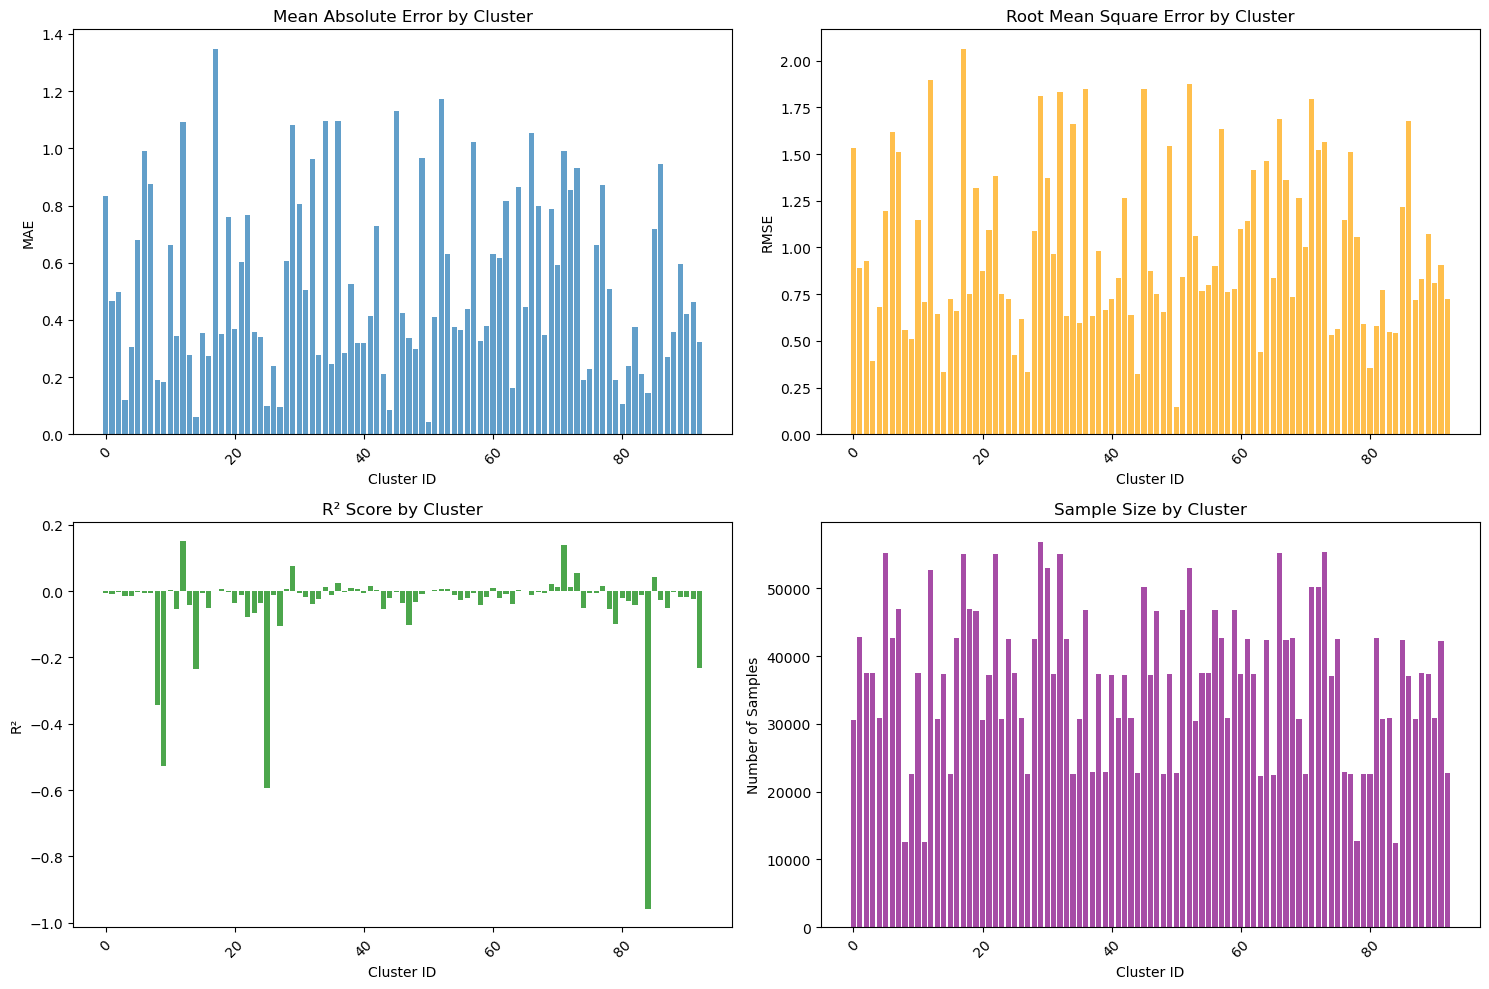


🎯 SUMMARY:
Successfully trained baseline models for 93 clusters
Total samples covered: 3,384,007
Average samples per cluster: 36387
Best performing cluster (lowest MAE): 50 (MAE: 0.043)
Worst performing cluster (highest MAE): 17 (MAE: 1.349)


In [11]:
# Save per-cluster baseline results
import os
import matplotlib.pyplot as plt

# Create a visualization of cluster performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# MAE by cluster
ax1.bar(results_df['cluster_id'], results_df['mae_mean'], alpha=0.7)
ax1.set_xlabel('Cluster ID')
ax1.set_ylabel('MAE')
ax1.set_title('Mean Absolute Error by Cluster')
ax1.tick_params(axis='x', rotation=45)

# RMSE by cluster
ax2.bar(results_df['cluster_id'], results_df['rmse_mean'], alpha=0.7, color='orange')
ax2.set_xlabel('Cluster ID')
ax2.set_ylabel('RMSE')
ax2.set_title('Root Mean Square Error by Cluster')
ax2.tick_params(axis='x', rotation=45)

# R2 by cluster (if available)
if len(r2_values) > 0:
    valid_r2_df = results_df.dropna(subset=['r2_mean'])
    ax3.bar(valid_r2_df['cluster_id'], valid_r2_df['r2_mean'], alpha=0.7, color='green')
    ax3.set_xlabel('Cluster ID')
    ax3.set_ylabel('R²')
    ax3.set_title('R² Score by Cluster')
    ax3.tick_params(axis='x', rotation=45)
else:
    ax3.text(0.5, 0.5, 'No valid R² values', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('R² Score by Cluster (No Data)')

# Sample size by cluster
ax4.bar(results_df['cluster_id'], results_df['n_samples'], alpha=0.7, color='purple')
ax4.set_xlabel('Cluster ID')
ax4.set_ylabel('Number of Samples')
ax4.set_title('Sample Size by Cluster')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n🎯 SUMMARY:")
print(f"Successfully trained baseline models for {len(successful_clusters)} clusters")
print(f"Total samples covered: {results_df['n_samples'].sum():,}")
print(f"Average samples per cluster: {results_df['n_samples'].mean():.0f}")
print(f"Best performing cluster (lowest MAE): {results_df.loc[results_df['mae_mean'].idxmin(), 'cluster_id']} (MAE: {results_df['mae_mean'].min():.3f})")
print(f"Worst performing cluster (highest MAE): {results_df.loc[results_df['mae_mean'].idxmax(), 'cluster_id']} (MAE: {results_df['mae_mean'].max():.3f})")


In [12]:
# Import XGBoost for training
import xgboost as xgb
from scipy.stats import skellam

def train_cluster_xgb_baseline(cluster_data, cluster_id, feature_cols, target_A, target_D, 
                              n_splits=3, objective='reg:squarederror', LAMBDA_MAX=40.0):
    """
    Train XGBoost models per cluster for both arrivals and departures.
    
    Parameters:
    -----------
    cluster_data : pd.DataFrame
        Data for a specific cluster
    cluster_id : int
        Cluster identifier
    feature_cols : list
        List of feature columns
    target_A : str
        Target column for arrivals
    target_D : str
        Target column for departures
    n_splits : int
        Number of cross-validation splits
    objective : str
        XGBoost objective ('reg:squarederror' or 'count:poisson')
    LAMBDA_MAX : float
        Maximum lambda threshold for outlier detection
    
    Returns:
    --------
    dict : Dictionary with training results and metrics
    """
    try:
        # Sort by time to avoid data leakage in time series CV
        cluster_data = cluster_data.sort_values("ts_start").reset_index(drop=True)

        # Prepare features
        X_full = (cluster_data[feature_cols]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(cluster_data[feature_cols].median())
            .astype(np.float64)
        )
        
        # Additional safety check for any remaining NaNs
        if X_full.isna().any().any():
            print(f"⚠️  Warning: Still have NaNs after fillna, filling with 0")
            X_full = X_full.fillna(0)

        y_A_full = np.maximum(cluster_data[target_A].values, 0).astype(np.float64)
        y_D_full = np.maximum(cluster_data[target_D].values, 0).astype(np.float64)

        print(f"[{cluster_id}] Training XGB ({objective}) - samples = {len(cluster_data):,}")

        tscv = TimeSeriesSplit(n_splits=n_splits)
        fold_results = []

        for fold, (train_idx, test_idx) in enumerate(tscv.split(X_full)):
            # Prepare data
            X_train = X_full.iloc[train_idx]
            X_test = X_full.iloc[test_idx]
            yA_tr, yA_ts = y_A_full[train_idx], y_A_full[test_idx]
            yD_tr, yD_ts = y_D_full[train_idx], y_D_full[test_idx]

            # XGBoost parameters
            xgb_params = {
                'objective': objective,
                'eval_metric': 'mae',
                'verbosity': 0,
                'seed': 42,
                'n_estimators': 1000,
                'max_depth': 10,
                'learning_rate': 0.1,
                'subsample': 0.8,
                'colsample_bytree': 0.8
            }

            # Train models for arrivals and departures
            model_A = xgb.XGBRegressor(**xgb_params)
            model_D = xgb.XGBRegressor(**xgb_params)
            
            model_A.fit(X_train, yA_tr)
            model_D.fit(X_train, yD_tr)

            # Predictions on test set
            λA = model_A.predict(X_test)
            λD = model_D.predict(X_test)

            # Predictions on training set for train metrics
            λA_train = model_A.predict(X_train)
            λD_train = model_D.predict(X_train)

            # For count:poisson, ensure non-negative predictions
            if objective == 'count:poisson':
                λA = np.maximum(λA, 0)
                λD = np.maximum(λD, 0)
                λA_train = np.maximum(λA_train, 0)
                λD_train = np.maximum(λD_train, 0)

            # Detect and show outliers
            bad_mask = (λA > LAMBDA_MAX) | (λD > LAMBDA_MAX)
            if bad_mask.any():
                outlier_count = bad_mask.sum()
                print(f"🚨 Fold {fold} – Found {outlier_count} outliers (λ > {LAMBDA_MAX})")
                
            # Remove outliers
            keep_mask = ~bad_mask
            if keep_mask.sum() == 0:
                print(f"⚠️  Fold {fold} discarded: only outliers")
                continue

            λA, λD = λA[keep_mask], λD[keep_mask]
            y_delta_ts = (yA_ts - yD_ts)[keep_mask]
            point_fcst = λA - λD
            var_fcst = λA + λD

            # Test metrics
            mae = mean_absolute_error(y_delta_ts, point_fcst)
            rmse = np.sqrt(mean_squared_error(y_delta_ts, point_fcst))
            r2 = r2_score(y_delta_ts, point_fcst) if len(np.unique(y_delta_ts)) > 1 else np.nan

            # Train metrics
            y_delta_tr = yA_tr - yD_tr
            point_fcst_train = λA_train - λD_train
            mae_train = mean_absolute_error(y_delta_tr, point_fcst_train)
            rmse_train = np.sqrt(mean_squared_error(y_delta_tr, point_fcst_train))
            r2_train = r2_score(y_delta_tr, point_fcst_train) if len(np.unique(y_delta_tr)) > 1 else np.nan

            # Skellam log-likelihood (if using Poisson-like predictions)
            try:
                ll = skellam.logpmf(y_delta_ts.astype(int), λA, λD).sum()
            except Exception:
                ll = np.nan

            try:
                ll_train = skellam.logpmf(y_delta_tr.astype(int), λA_train, λD_train).sum()
            except Exception:
                ll_train = np.nan

            # PIT calibration
            try:
                pit_ks = np.abs(
                    np.sort(skellam.cdf(y_delta_ts.astype(int), λA, λD))
                    - np.linspace(0, 1, len(y_delta_ts))
                ).max()
            except Exception:
                pit_ks = np.nan

            try:
                pit_ks_train = np.abs(
                    np.sort(skellam.cdf(y_delta_tr.astype(int), λA_train, λD_train))
                    - np.linspace(0, 1, len(y_delta_tr))
                ).max()
            except Exception:
                pit_ks_train = np.nan

            fold_results.append({
                'fold': fold,
                'mae': mae,
                'rmse': rmse,
                'r2': r2,
                'll': ll,
                'pit_ks': pit_ks,
                'mae_train': mae_train,
                'rmse_train': rmse_train,
                'r2_train': r2_train,
                'll_train': ll_train,
                'pit_ks_train': pit_ks_train,
                'lambda_A_mean': λA.mean(),
                'lambda_D_mean': λD.mean(),
                'lambda_A_train_mean': λA_train.mean(),
                'lambda_D_train_mean': λD_train.mean(),
                'var_forecast_mean': var_fcst.mean(),
                'n_test': len(y_delta_ts),
                'n_train': len(y_delta_tr)
            })

        # Aggregate results
        if not fold_results:
            raise RuntimeError("No valid folds (all were discarded).")

        agg = lambda k: np.mean([d[k] for d in fold_results if not np.isnan(d[k])])

        return {
            'cluster_id': cluster_id,
            'model_type': f'XGB_{objective}',
            'n_samples': len(cluster_data),
            'n_folds': len(fold_results),
            'mae_mean': agg('mae'),
            'rmse_mean': agg('rmse'),
            'r2_mean': agg('r2'),
            'log_likelihood_mean': agg('ll'),
            'pit_ks_mean': agg('pit_ks'),
            'mae_train_mean': agg('mae_train'),
            'rmse_train_mean': agg('rmse_train'),
            'r2_train_mean': agg('r2_train'),
            'log_likelihood_train_mean': agg('ll_train'),
            'pit_ks_train_mean': agg('pit_ks_train'),
            'lambda_A_mean': agg('lambda_A_mean'),
            'lambda_D_mean': agg('lambda_D_mean'),
            'lambda_A_train_mean': agg('lambda_A_train_mean'),
            'lambda_D_train_mean': agg('lambda_D_train_mean'),
            'convergence_success': True
        }

    except Exception as e:
        print(f"❌ Error in cluster {cluster_id}: {e}")
        return {
            'cluster_id': cluster_id,
            'model_type': f'XGB_{objective}',
            'n_samples': len(cluster_data),
            'convergence_success': False,
            'error': str(e)
        }

print("✅ XGBoost per-cluster training function defined")


✅ XGBoost per-cluster training function defined


In [13]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
# Train XGBoost models with normal objective (reg:squarederror)
print("Training XGBoost models with normal objective (reg:squarederror)...")

# Get unique cluster IDs (same as before)
active_cluster_ids = sorted(df_merged['cluster'].unique())
print(f"Processing {len(active_cluster_ids)} clusters with XGBoost normal objective...")

xgb_normal_results = []
for i, cluster_id in enumerate(active_cluster_ids):
    print(f"  [{i+1}/{len(active_cluster_ids)}] Training XGB Normal cluster {cluster_id}...")
    
    # Filter data for this cluster using Polars filter method
    cluster_data = df_merged.filter(pl.col('cluster') == cluster_id).to_pandas()
    #print(f"    Samples: {len(cluster_data):,}")
    
    # Train cluster-specific XGBoost with normal objective
    result = train_cluster_xgb_baseline(
        cluster_data, cluster_id, 
        feature_cols=feature_cols, 
        target_A=target_A, 
        target_D=target_D,
        n_splits=3, 
        objective='reg:squarederror'
    )
    xgb_normal_results.append(result)
    
    if result['convergence_success']:
        print(f"    ✅ MAE: {result['mae_mean']:.3f}, RMSE: {result['rmse_mean']:.3f}, R2: {result.get('r2_mean', 'N/A')}")
    else:
        print(f"    ❌ Failed: {result.get('error', 'Unknown error')}")

print(f"\n✅ Completed XGBoost normal training for {len(active_cluster_ids)} clusters")
successful_xgb_normal = [r for r in xgb_normal_results if r['convergence_success']]
print(f"Successful clusters: {len(successful_xgb_normal)}/{len(active_cluster_ids)}")

# Print summary of train metrics
if successful_xgb_normal:
    print("\n📊 XGBoost Normal - Training Metrics Summary:")
    train_maes = [r['mae_train_mean'] for r in successful_xgb_normal if 'mae_train_mean' in r and not np.isnan(r['mae_train_mean'])]
    train_rmses = [r['rmse_train_mean'] for r in successful_xgb_normal if 'rmse_train_mean' in r and not np.isnan(r['rmse_train_mean'])]
    train_r2s = [r['r2_train_mean'] for r in successful_xgb_normal if 'r2_train_mean' in r and not np.isnan(r['r2_train_mean'])]
    
    if train_maes:
        print(f"  Train MAE - Mean: {np.mean(train_maes):.3f}, Std: {np.std(train_maes):.3f}")
    if train_rmses:
        print(f"  Train RMSE - Mean: {np.mean(train_rmses):.3f}, Std: {np.std(train_rmses):.3f}")
    if train_r2s:
        print(f"  Train R² - Mean: {np.mean(train_r2s):.3f}, Std: {np.std(train_r2s):.3f}")


Training XGBoost models with normal objective (reg:squarederror)...
Processing 93 clusters with XGBoost normal objective...
  [1/93] Training XGB Normal cluster 0...
[0] Training XGB (reg:squarederror) - samples = 30,630
    ✅ MAE: 0.970, RMSE: 1.611, R2: -0.11178762409363234
  [2/93] Training XGB Normal cluster 1...
[1] Training XGB (reg:squarederror) - samples = 42,747
    ✅ MAE: 0.586, RMSE: 0.944, R2: -0.14090849489050136
  [3/93] Training XGB Normal cluster 2...
[2] Training XGB (reg:squarederror) - samples = 37,510
    ✅ MAE: 0.620, RMSE: 0.979, R2: -0.12462013741541744
  [4/93] Training XGB Normal cluster 3...
[3] Training XGB (reg:squarederror) - samples = 37,454
    ✅ MAE: 0.178, RMSE: 0.416, R2: -0.1417967608538039
  [5/93] Training XGB Normal cluster 4...
[4] Training XGB (reg:squarederror) - samples = 30,874
    ✅ MAE: 0.415, RMSE: 0.735, R2: -0.18942855527455582
  [6/93] Training XGB Normal cluster 5...
[5] Training XGB (reg:squarederror) - samples = 55,147
    ✅ MAE: 0.82

KeyboardInterrupt: 

In [15]:
print(f"\n✅ Completed XGBoost normal training for {len(active_cluster_ids)} clusters")
successful_xgb_normal = [r for r in xgb_normal_results if r['convergence_success']]
print(f"Successful clusters: {len(successful_xgb_normal)}/{len(active_cluster_ids)}")

# Print summary of train metrics
if successful_xgb_normal:
    print("\n📊 XGBoost Normal - Training Metrics Summary:")
    train_maes = [r['mae_train_mean'] for r in successful_xgb_normal if 'mae_train_mean' in r and not np.isnan(r['mae_train_mean'])]
    train_rmses = [r['rmse_train_mean'] for r in successful_xgb_normal if 'rmse_train_mean' in r and not np.isnan(r['rmse_train_mean'])]
    train_r2s = [r['r2_train_mean'] for r in successful_xgb_normal if 'r2_train_mean' in r and not np.isnan(r['r2_train_mean'])]
    
    if train_maes:
        print(f"  Train MAE - Mean: {np.mean(train_maes):.3f}, Std: {np.std(train_maes):.3f}")
    if train_rmses:
        print(f"  Train RMSE - Mean: {np.mean(train_rmses):.3f}, Std: {np.std(train_rmses):.3f}")
    if train_r2s:
        print(f"  Train R² - Mean: {np.mean(train_r2s):.3f}, Std: {np.std(train_r2s):.3f}")


✅ Completed XGBoost normal training for 93 clusters
Successful clusters: 29/93

📊 XGBoost Normal - Training Metrics Summary:
  Train MAE - Mean: 0.005, Std: 0.004
  Train RMSE - Mean: 0.008, Std: 0.007
  Train R² - Mean: 1.000, Std: 0.000


In [21]:
# Train XGBoost models with Poisson objective (count:poisson)
print("Training XGBoost models with Poisson objective (count:poisson)...")

xgb_poisson_results = []
for i, cluster_id in enumerate(active_cluster_ids):
    print(f"  [{i+1}/{len(active_cluster_ids)}] Training XGB Poisson cluster {cluster_id}...")
    
    # Filter data for this cluster using Polars filter method
    cluster_data = df_merged.filter(pl.col('cluster') == cluster_id).to_pandas()
    print(f"    Samples: {len(cluster_data):,}")
    
    # Train cluster-specific XGBoost with Poisson objective
    result = train_cluster_xgb_baseline(
        cluster_data, cluster_id, 
        feature_cols=feature_cols, 
        target_A=target_A, 
        target_D=target_D,
        n_splits=3, 
        objective='count:poisson'
    )
    xgb_poisson_results.append(result)
    
    if result['convergence_success']:
        print(f"    ✅ MAE: {result['mae_mean']:.3f}, RMSE: {result['rmse_mean']:.3f}, R2: {result.get('r2_mean', 'N/A')}")
    else:
        print(f"    ❌ Failed: {result.get('error', 'Unknown error')}")

print(f"\n✅ Completed XGBoost Poisson training for {len(active_cluster_ids)} clusters")
successful_xgb_poisson = [r for r in xgb_poisson_results if r['convergence_success']]
print(f"Successful clusters: {len(successful_xgb_poisson)}/{len(active_cluster_ids)}")

# Print summary of train metrics
if successful_xgb_normal:
    print("\n📊 XGBoost Normal - Training Metrics Summary:")
    train_maes = [r['mae_train_mean'] for r in successful_xgb_normal if 'mae_train_mean' in r and not np.isnan(r['mae_train_mean'])]
    train_rmses = [r['rmse_train_mean'] for r in successful_xgb_normal if 'rmse_train_mean' in r and not np.isnan(r['rmse_train_mean'])]
    train_r2s = [r['r2_train_mean'] for r in successful_xgb_normal if 'r2_train_mean' in r and not np.isnan(r['r2_train_mean'])]
    
    if train_maes:
        print(f"  Train MAE - Mean: {np.mean(train_maes):.3f}, Std: {np.std(train_maes):.3f}")
    if train_rmses:
        print(f"  Train RMSE - Mean: {np.mean(train_rmses):.3f}, Std: {np.std(train_rmses):.3f}")
    if train_r2s:
        print(f"  Train R² - Mean: {np.mean(train_r2s):.3f}, Std: {np.std(train_r2s):.3f}")

Training XGBoost models with Poisson objective (count:poisson)...
  [1/93] Training XGB Poisson cluster 0...
    Samples: 30,630
[0] Training XGB (count:poisson) - samples = 30,630
    ✅ MAE: 0.858, RMSE: 1.538, R2: -0.01372235260222654
  [2/93] Training XGB Poisson cluster 1...
    Samples: 42,747
[1] Training XGB (count:poisson) - samples = 42,747
    ✅ MAE: 0.488, RMSE: 0.893, R2: -0.020264305087025553
  [3/93] Training XGB Poisson cluster 2...
    Samples: 37,510
[2] Training XGB (count:poisson) - samples = 37,510
    ✅ MAE: 0.522, RMSE: 0.930, R2: -0.014442636166214365
  [4/93] Training XGB Poisson cluster 3...
    Samples: 37,454
[3] Training XGB (count:poisson) - samples = 37,454
    ✅ MAE: 0.125, RMSE: 0.393, R2: -0.017545086121170856
  [5/93] Training XGB Poisson cluster 4...
    Samples: 30,874
[4] Training XGB (count:poisson) - samples = 30,874
    ✅ MAE: 0.325, RMSE: 0.688, R2: -0.0409160926373929
  [6/93] Training XGB Poisson cluster 5...
    Samples: 55,147
[5] Training X

In [22]:
# Comprehensive analysis and comparison of all models
print("=== COMPREHENSIVE MODEL COMPARISON ===")
print()

# Convert all results to DataFrames
print("📊 MODEL PERFORMANCE SUMMARY:")
print()

# Poisson Regressor results
poisson_df = pd.DataFrame(successful_clusters)
poisson_df['model_type'] = 'Poisson_Regressor'

# XGBoost Normal results
xgb_normal_df = pd.DataFrame(successful_xgb_normal)

# XGBoost Poisson results
xgb_poisson_df = pd.DataFrame(successful_xgb_poisson)

# Combine all results
all_results = pd.concat([poisson_df, xgb_normal_df, xgb_poisson_df], ignore_index=True)

print("🎯 OVERALL PERFORMANCE METRICS:")
for model_type in ['Poisson_Regressor', 'XGB_reg:squarederror', 'XGB_count:poisson']:
    model_data = all_results[all_results['model_type'] == model_type]
    if len(model_data) > 0:
        print(f"\n{model_type}:")
        print(f"  Successful clusters: {len(model_data)}")
        print(f"  Average MAE: {model_data['mae_mean'].mean():.3f} ± {model_data['mae_mean'].std():.3f}")
        print(f"  Average RMSE: {model_data['rmse_mean'].mean():.3f} ± {model_data['rmse_mean'].std():.3f}")
        
        # Handle R2 which might have NaN values
        r2_values = model_data['r2_mean'].dropna()
        if len(r2_values) > 0:
            print(f"  Average R2: {r2_values.mean():.3f} ± {r2_values.std():.3f}")
        else:
            print("  Average R2: N/A")

# Find best performing model per cluster
print("\n🏆 BEST MODEL PER CLUSTER (by MAE):")
best_models = []
for cluster_id in active_cluster_ids:
    cluster_results = all_results[all_results['cluster_id'] == cluster_id]
    if len(cluster_results) > 0:
        best_idx = cluster_results['mae_mean'].idxmin()
        best_model = cluster_results.loc[best_idx]
        best_models.append({
            'cluster_id': cluster_id,
            'best_model': best_model['model_type'],
            'best_mae': best_model['mae_mean'],
            'best_rmse': best_model['rmse_mean'],
            'best_r2': best_model['r2_mean']
        })

best_models_df = pd.DataFrame(best_models)

# Count wins per model type
model_wins = best_models_df['best_model'].value_counts()
print(f"\nModel wins count:")
for model, wins in model_wins.items():
    print(f"  {model}: {wins} clusters ({wins/len(best_models_df)*100:.1f}%)")

print(f"\nTop 10 best performing clusters:")
print(best_models_df.nsmallest(10, 'best_mae')[['cluster_id', 'best_model', 'best_mae', 'best_rmse', 'best_r2']].round(3))


=== COMPREHENSIVE MODEL COMPARISON ===

📊 MODEL PERFORMANCE SUMMARY:

🎯 OVERALL PERFORMANCE METRICS:

Poisson_Regressor:
  Successful clusters: 93
  Average MAE: 0.528 ± 0.317
  Average RMSE: 0.998 ± 0.452
  Average R2: -0.041 ± 0.138

XGB_reg:squarederror:
  Successful clusters: 93
  Average MAE: 0.560 ± 0.318
  Average RMSE: 1.006 ± 0.460
  Average R2: -0.045 ± 0.052

XGB_count:poisson:
  Successful clusters: 93
  Average MAE: 0.539 ± 0.319
  Average RMSE: 0.990 ± 0.457
  Average R2: -0.006 ± 0.041

🏆 BEST MODEL PER CLUSTER (by MAE):

Model wins count:
  Poisson_Regressor: 79 clusters (84.9%)
  XGB_count:poisson: 14 clusters (15.1%)

Top 10 best performing clusters:
    cluster_id         best_model  best_mae  best_rmse  best_r2
50          50  Poisson_Regressor     0.043      0.148   -0.000
14          14  XGB_count:poisson     0.057      0.297   -0.005
44          44  Poisson_Regressor     0.085      0.322   -0.021
27          27  Poisson_Regressor     0.095      0.332   -0.106
25 

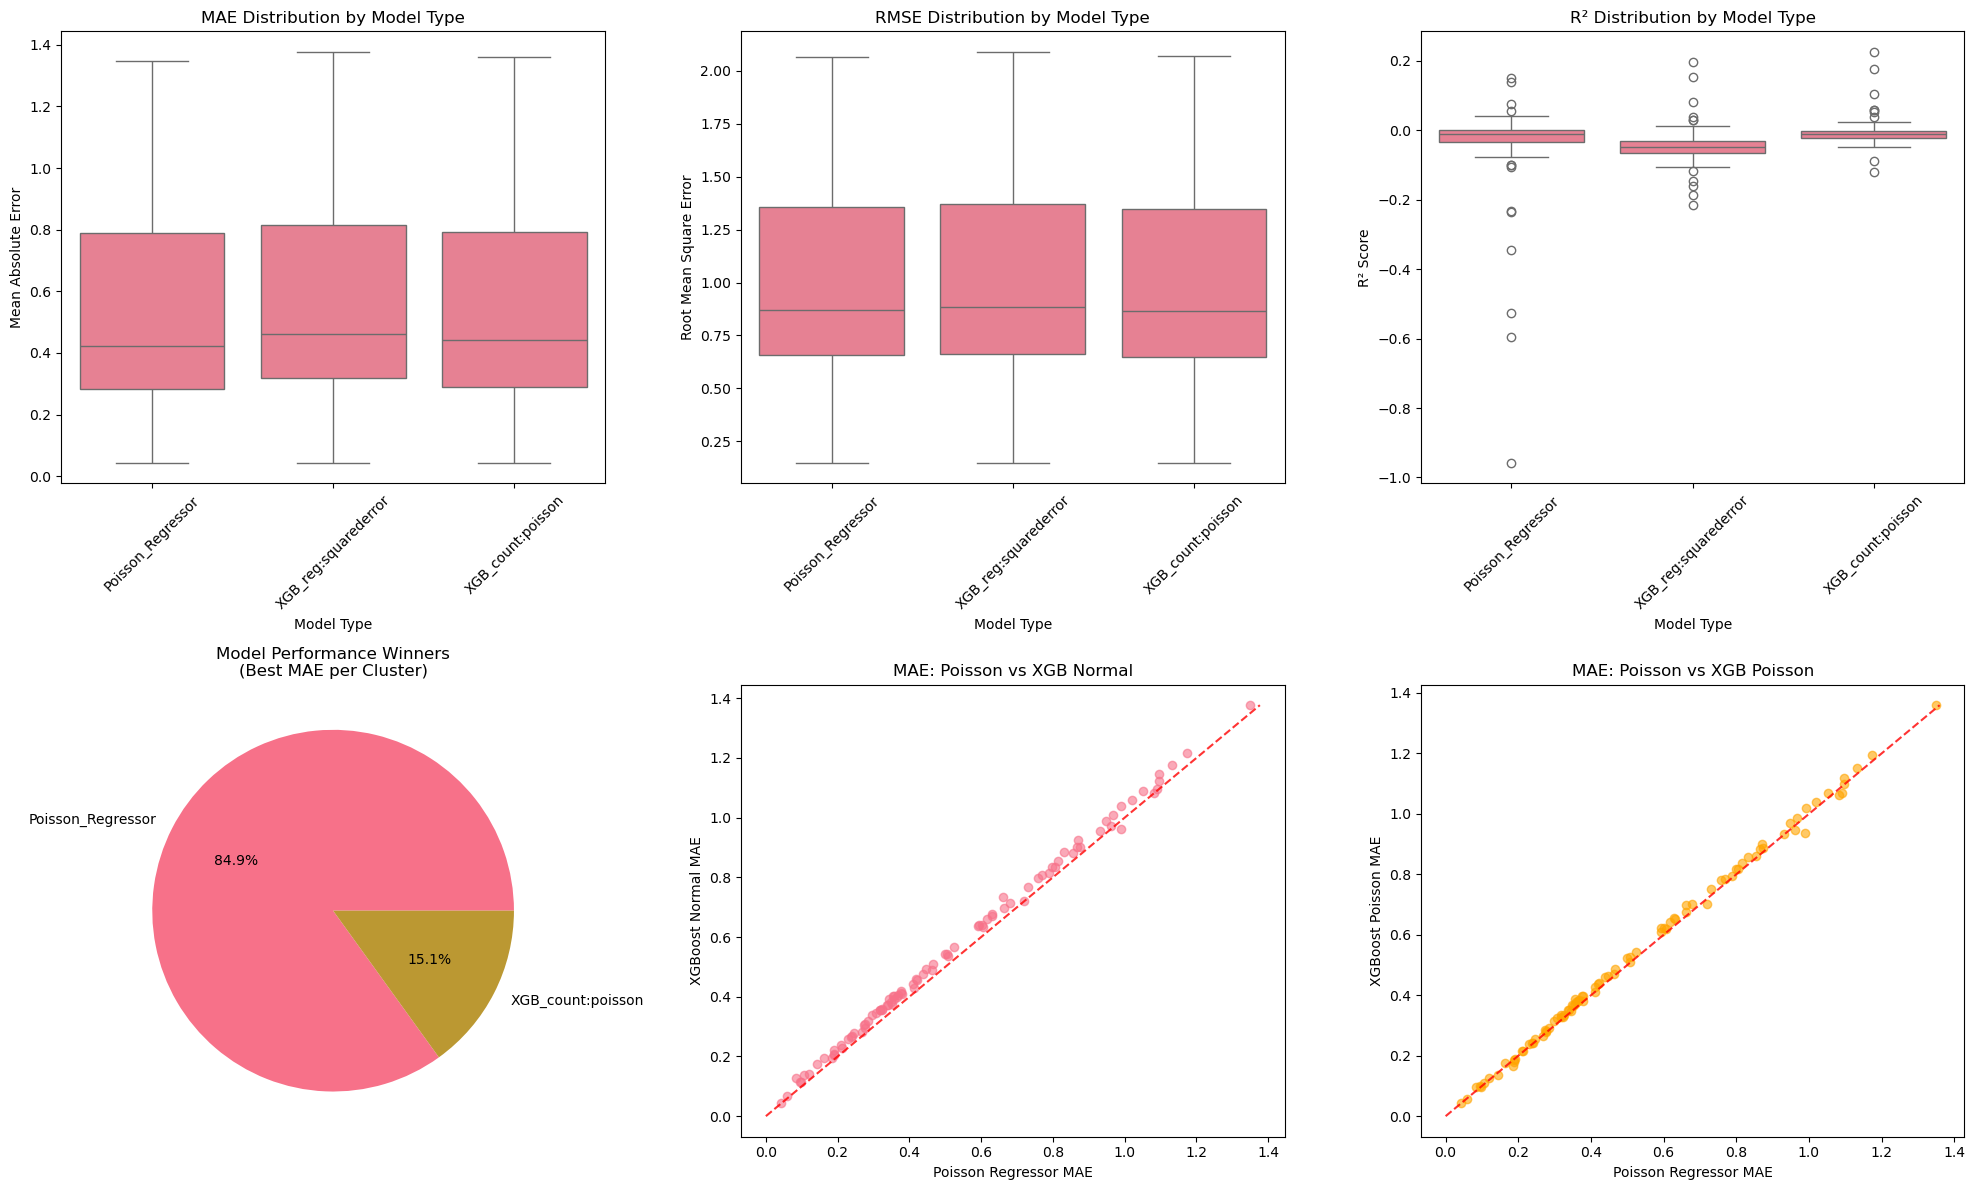


📈 PERFORMANCE INSIGHTS:
- Total clusters analyzed: 93
- Poisson Regressor successful: 93
- XGBoost Normal successful: 93
- XGBoost Poisson successful: 93
- Average MAE improvement XGB Normal vs Poisson: -8.7%
- Average MAE improvement XGB Poisson vs Poisson: -2.4%


In [16]:
# Visualization of model comparison
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. MAE comparison boxplot
sns.boxplot(data=all_results, x='model_type', y='mae_mean', ax=axes[0,0])
axes[0,0].set_title('MAE Distribution by Model Type')
axes[0,0].set_xlabel('Model Type')
axes[0,0].set_ylabel('Mean Absolute Error')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. RMSE comparison boxplot
sns.boxplot(data=all_results, x='model_type', y='rmse_mean', ax=axes[0,1])
axes[0,1].set_title('RMSE Distribution by Model Type')
axes[0,1].set_xlabel('Model Type')
axes[0,1].set_ylabel('Root Mean Square Error')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. R2 comparison boxplot (excluding NaN values)
all_results_clean_r2 = all_results.dropna(subset=['r2_mean'])
if len(all_results_clean_r2) > 0:
    sns.boxplot(data=all_results_clean_r2, x='model_type', y='r2_mean', ax=axes[0,2])
    axes[0,2].set_title('R² Distribution by Model Type')
    axes[0,2].set_xlabel('Model Type')
    axes[0,2].set_ylabel('R² Score')
    axes[0,2].tick_params(axis='x', rotation=45)
else:
    axes[0,2].text(0.5, 0.5, 'No valid R² values', ha='center', va='center', transform=axes[0,2].transAxes)

# 4. Model wins pie chart
model_wins.plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Model Performance Winners\n(Best MAE per Cluster)')
axes[1,0].set_ylabel('')

# 5. MAE scatter plot: Poisson vs XGB Normal
poisson_mae = poisson_df.set_index('cluster_id')['mae_mean']
xgb_normal_mae = xgb_normal_df.set_index('cluster_id')['mae_mean'] 
common_clusters = poisson_mae.index.intersection(xgb_normal_mae.index)

if len(common_clusters) > 0:
    axes[1,1].scatter(poisson_mae[common_clusters], xgb_normal_mae[common_clusters], alpha=0.6)
    axes[1,1].plot([0, max(poisson_mae[common_clusters].max(), xgb_normal_mae[common_clusters].max())], 
                   [0, max(poisson_mae[common_clusters].max(), xgb_normal_mae[common_clusters].max())], 
                   'r--', alpha=0.8)
    axes[1,1].set_xlabel('Poisson Regressor MAE')
    axes[1,1].set_ylabel('XGBoost Normal MAE')
    axes[1,1].set_title('MAE: Poisson vs XGB Normal')

# 6. MAE scatter plot: Poisson vs XGB Poisson
xgb_poisson_mae = xgb_poisson_df.set_index('cluster_id')['mae_mean']
common_clusters_poisson = poisson_mae.index.intersection(xgb_poisson_mae.index)

if len(common_clusters_poisson) > 0:
    axes[1,2].scatter(poisson_mae[common_clusters_poisson], xgb_poisson_mae[common_clusters_poisson], alpha=0.6, color='orange')
    axes[1,2].plot([0, max(poisson_mae[common_clusters_poisson].max(), xgb_poisson_mae[common_clusters_poisson].max())], 
                   [0, max(poisson_mae[common_clusters_poisson].max(), xgb_poisson_mae[common_clusters_poisson].max())], 
                   'r--', alpha=0.8)
    axes[1,2].set_xlabel('Poisson Regressor MAE')
    axes[1,2].set_ylabel('XGBoost Poisson MAE')
    axes[1,2].set_title('MAE: Poisson vs XGB Poisson')

plt.tight_layout()
plt.show()

print(f"\n📈 PERFORMANCE INSIGHTS:")
print(f"- Total clusters analyzed: {len(active_cluster_ids)}")
print(f"- Poisson Regressor successful: {len(successful_clusters)}")
print(f"- XGBoost Normal successful: {len(successful_xgb_normal)}")
print(f"- XGBoost Poisson successful: {len(successful_xgb_poisson)}")

# Calculate improvement percentages
if len(common_clusters) > 0:
    mae_improvement_normal = ((poisson_mae[common_clusters] - xgb_normal_mae[common_clusters]) / poisson_mae[common_clusters] * 100).mean()
    print(f"- Average MAE improvement XGB Normal vs Poisson: {mae_improvement_normal:.1f}%")

if len(common_clusters_poisson) > 0:
    mae_improvement_poisson = ((poisson_mae[common_clusters_poisson] - xgb_poisson_mae[common_clusters_poisson]) / poisson_mae[common_clusters_poisson] * 100).mean()
    print(f"- Average MAE improvement XGB Poisson vs Poisson: {mae_improvement_poisson:.1f}%")
